# Abbildungen: Ground-Truth-Ergebnisse (Kapitel 5.7)

Erzeugt die Abbildungen für den Abschnitt "Ergebnisse: Prototyp und Ground Truth" (Kernstichprobe n=50, Extremfälle n=20). Stilistisch an Notebook 15 (Modellauswahl-Abbildungen) angelehnt, damit alle Abbildungen der Thesis dieselbe Farb- und Formsprache teilen.

In [1]:
# ---------------------------------------------------------------------------
# EINGABE
# ---------------------------------------------------------------------------
# Kernstichprobe (n=50): finaler GPT-5.5-Lauf, identisch zu den in 5.6 berichteten
# Zahlen (Tabelle "Kennzahlenvergleich der Kandidatenmodelle").
KERN_RUN = "outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5"
KERN_GT = "data/sample_2026-06-25_09-57/ground_truth_template_slim_v2.csv"
KERN_KENNZAHLEN = "outputs/ground_truth/2026-07-16_11-38-35_figures_gpt5_5/eval_kennzahlen.json"

# Extremfaelle (n=20): finaler, blind bewerteter Stand (je 10 gut/schlecht
# konstruierte Datensaetze). Kennzahlen-JSON wurde mit Notebook 10 erzeugt
# (Abschnitt 3c, Ceiling- und Disattenuationsanalyse inklusive).
EXTREM_RUN = "outputs/runs/run_2026-07-22_09-23-07_state-evaluation-final_EVAL"
EXTREM_GT = "data/extreme_cases_05/ground_truth_template_slim.csv"
EXTREM_KENNZAHLEN = "outputs/ground_truth/2026-07-22_extremfaelle_final/eval_kennzahlen.json"

AUSGABE_ORDNER = "thesis/images"

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

REPO_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(REPO_ROOT / "src"))

from evaluation import ground_truth as gt  # noqa: E402

out_dir = REPO_ROOT / AUSGABE_ORDNER
out_dir.mkdir(parents=True, exist_ok=True)

DIMS = ["findability", "accessibility", "reusability", "expressiveness"]
DIM_DE = {"findability": "Auffindbarkeit", "accessibility": "Zugänglichkeit",
          "reusability": "Wiederverwendbarkeit", "expressiveness": "Aussagekraft"}
LLM_DIM = "expressiveness"

kern_kennz = json.loads((REPO_ROOT / KERN_KENNZAHLEN).read_text(encoding="utf-8"))
extrem_kennz = json.loads((REPO_ROOT / EXTREM_KENNZAHLEN).read_text(encoding="utf-8"))

kern_merged = gt.merge_scores(
    gt.load_ground_truth(REPO_ROOT / KERN_GT),
    gt.load_model_scores(REPO_ROOT / KERN_RUN),
)
kern_result = gt.compare(kern_merged)

extrem_merged = gt.merge_scores(
    gt.load_ground_truth(REPO_ROOT / EXTREM_GT),
    gt.load_model_scores(REPO_ROOT / EXTREM_RUN),
)
extrem_result = gt.compare(extrem_merged)

print("Kernstichprobe:")
print(gt.summary_table(kern_result))
print()
print("Extremfälle:")
print(gt.summary_table(extrem_result))

loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5
loaded 20 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-22_09-23-07_state-evaluation-final_EVAL
Kernstichprobe:
                spearman  kendall_tau     n
findability        0.524        0.469  50.0
accessibility      0.712        0.601  50.0
reusability        0.739        0.694  50.0
expressiveness     0.569        0.465  50.0

Extremfälle:
                spearman  kendall_tau     n
findability        0.874        0.756  20.0
accessibility      0.713        0.525  20.0
reusability        0.872        0.769  20.0
expressiveness     0.321        0.255  20.0


In [3]:
# Palette identisch zu Notebook 15 (modellauswahl_*): HAUPT = FARBEN["GPT-5.5"],
# da saemtliche hier gezeigten Laeufe mit dem final gewaehlten Modell erhoben sind.
# CEILING ist eine helle Toenung von HAUPT (gleiche Groesse, "erreichbare Obergrenze"
# statt eigenstaendige Messreihe). VERDICT ist eine eigene, davon klar unterscheidbare
# Farbfamilie (Rot-Gelb-Gruen als semantische Ampel fuer schlecht/mittel/gut).
HAUPT = "#2a78d6"
CEILING = "#aec6e8"
VERDICT = {"gut": "#2f8f46", "mittel": "#d9a441", "schlecht": "#c9503f"}
TEXT, TEXT_SEK, GRID = "#0b0b0b", "#52514e", "#d8d7d2"


def stil(ax):
    for r in ("top", "right"):
        ax.spines[r].set_visible(False)
    for r in ("left", "bottom"):
        ax.spines[r].set_color(GRID)
    ax.tick_params(colors=TEXT_SEK, labelsize=9)


def speichern(fig, name):
    """PNG fuer die Vorschau, PDF als Vektor fuer LaTeX."""
    for endung in ("png", "pdf"):
        p = out_dir / f"{name}.{endung}"
        fig.savefig(p, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="none")
        print(f"geschrieben: {p.relative_to(REPO_ROOT)}")

## Abbildung 1/4: Spearman ρ je Dimension mit Ceiling-Einordnung

Je einmal für die Kernstichprobe (n=50) und die Extremfälle (n=20). Die helle Zweitfarbe zeigt das bei gegebener Ground-Truth-Verteilung maximal erreichbare ρ (Ceiling); der Abstand zwischen beiden Balken ist damit nicht automatisch ein Modellfehler, sondern kann ein Skalen-/Stichprobenartefakt sein.

geschrieben: thesis/images/gt_kernstichprobe_rho_dimension.png
geschrieben: thesis/images/gt_kernstichprobe_rho_dimension.pdf


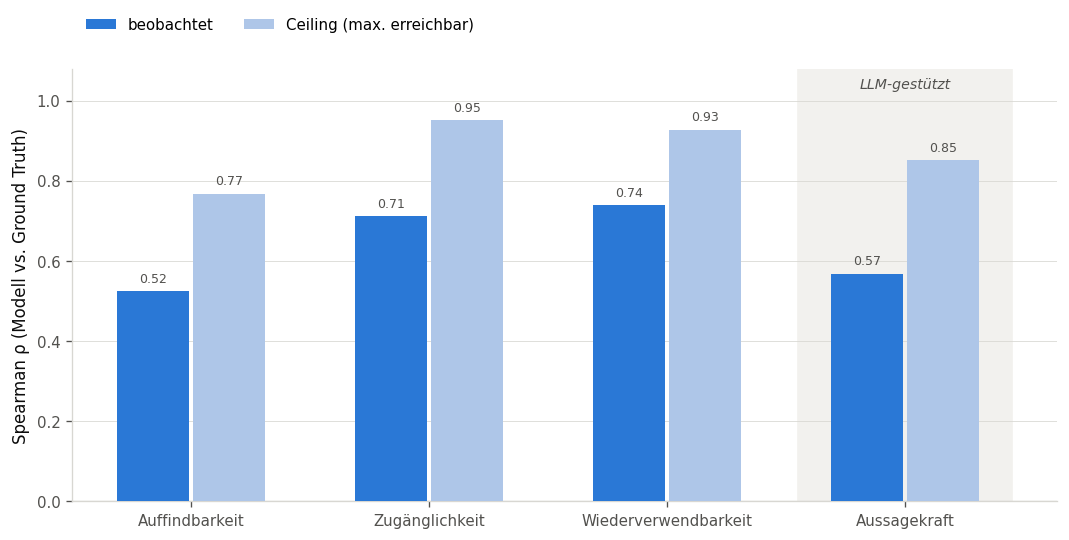

In [4]:
def fig_rho_ceiling(kennz, name):
    ceil = kennz["ceiling_analyse"]
    beob = [ceil[d]["spearman_beobachtet"] for d in DIMS]
    ceiling = [ceil[d]["spearman_ceiling"] for d in DIMS]

    fig, ax = plt.subplots(figsize=(9.0, 4.6))
    x, breite = np.arange(len(DIMS)), 0.32
    i_llm = DIMS.index(LLM_DIM)
    ax.axvspan(i_llm - 0.45, i_llm + 0.45, color="#f2f1ee", zorder=0)

    b1 = ax.bar(x - breite / 2, beob, breite * 0.95, label="beobachtet", color=HAUPT, zorder=3)
    b2 = ax.bar(x + breite / 2, ceiling, breite * 0.95, label="Ceiling (max. erreichbar)",
                color=CEILING, zorder=3)
    for bars in (b1, b2):
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h + 0.015, f"{h:.2f}", ha="center",
                    va="bottom", fontsize=7.5, color=TEXT_SEK, zorder=4)

    ax.set_ylabel("Spearman ρ (Modell vs. Ground Truth)", fontsize=10, color=TEXT)
    ax.set_ylim(0, 1.08)
    ax.set_xticks(x)
    ax.set_xticklabels([DIM_DE[d] for d in DIMS], fontsize=10, color=TEXT)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    ax.axhline(0, color=GRID, lw=0.8, zorder=2)
    stil(ax)
    ax.annotate("LLM-gestützt", xy=(i_llm, 1.03), ha="center", fontsize=8.5,
                color=TEXT_SEK, style="italic")
    ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left", bbox_to_anchor=(0.0, 1.15))
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_rho_ceiling(kern_kennz, "gt_kernstichprobe_rho_dimension")

In [5]:
fig_rho_ceiling(extrem_kennz, "gt_extremfaelle_rho_dimension")

geschrieben: thesis/images/gt_extremfaelle_rho_dimension.png
geschrieben: thesis/images/gt_extremfaelle_rho_dimension.pdf


## Abbildung 2/4: Modell- vs. Ground-Truth-Gesamturteil (Kernstichprobe)

Scatter der reskalierten Gesamtscores (0–5), eingefärbt nach dem GT-Urteil. Die gestrichelte Diagonale markiert perfekte Übereinstimmung.

geschrieben: thesis/images/gt_kernstichprobe_scatter.png
geschrieben: thesis/images/gt_kernstichprobe_scatter.pdf


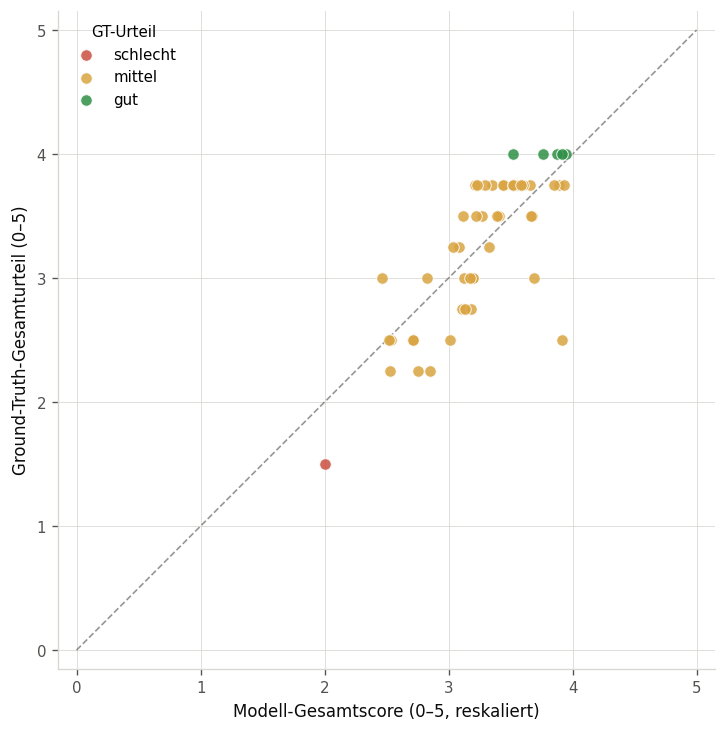

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
for v in gt.VERDICTS:
    sub = kern_merged[kern_merged["gt_verdict"] == v]
    ax.scatter(sub["model_overall_0_5"], sub["gt_overall"], label=v, s=48,
               color=VERDICT[v], alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3)
ax.plot([0, 5], [0, 5], linestyle="--", color=TEXT_SEK, lw=1, alpha=0.6, zorder=2)
ax.set_xlabel("Modell-Gesamtscore (0–5, reskaliert)", fontsize=10, color=TEXT)
ax.set_ylabel("Ground-Truth-Gesamturteil (0–5)", fontsize=10, color=TEXT)
ax.set_xlim(-0.15, 5.15)
ax.set_ylim(-0.15, 5.15)
ax.set_aspect("equal")
ax.set_axisbelow(True)
ax.grid(linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
ax.legend(title="GT-Urteil", frameon=False, fontsize=9, title_fontsize=9, loc="upper left")
fig.tight_layout()
speichern(fig, "gt_kernstichprobe_scatter")
plt.show()

## Abbildung 3/4: Konfusionsmatrix (Kernstichprobe)

Sequentielle Colormap in derselben Grundfarbe wie die übrigen Abbildungen, damit die Matrix nicht wie ein Fremdkörper im Kapitel wirkt.

geschrieben: thesis/images/gt_kernstichprobe_konfusionsmatrix.png
geschrieben: thesis/images/gt_kernstichprobe_konfusionsmatrix.pdf


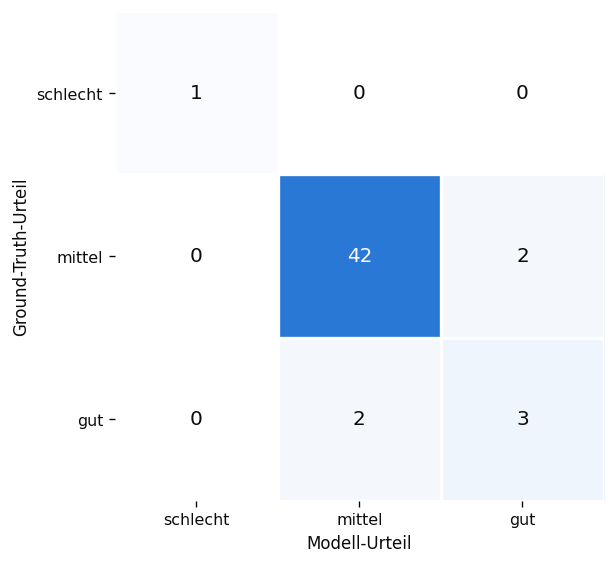

In [7]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("haupt", ["#ffffff", HAUPT])
cm = kern_result["confusion"]
data = cm.to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.8))
ax.imshow(data, cmap=cmap, vmin=0, vmax=data.max())
ax.set_xticks(range(len(cm.columns)))
ax.set_xticklabels([c.replace("M:", "") for c in cm.columns], fontsize=9.5, color=TEXT)
ax.set_yticks(range(len(cm.index)))
ax.set_yticklabels([i.replace("GT:", "") for i in cm.index], fontsize=9.5, color=TEXT)
ax.set_xlabel("Modell-Urteil", fontsize=10, color=TEXT)
ax.set_ylabel("Ground-Truth-Urteil", fontsize=10, color=TEXT)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = int(data[i, j])
        farbe = "white" if val > data.max() * 0.55 else TEXT
        ax.text(j, i, val, ha="center", va="center", color=farbe, fontsize=12, zorder=3)
for r in ax.spines.values():
    r.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(cm.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(cm.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
fig.tight_layout()
speichern(fig, "gt_kernstichprobe_konfusionsmatrix")
plt.show()

## Abbildung 4/4: Trennschärfe auf den Extremfällen

Modell-Gesamtscore je Datensatz, gruppiert nach Konstruktionsabsicht (`good_*` vs. `bad_*`). Diese Abbildung nutzt bewusst die Konstruktionskategorie statt des GT-Urteils, weil sie den beabsichtigten Mechanismus zeigt, nicht die Übereinstimmung mit der manuellen Bewertung (die steckt in Abbildung 1).

geschrieben: thesis/images/gt_extremfaelle_trennschaerfe.png
geschrieben: thesis/images/gt_extremfaelle_trennschaerfe.pdf


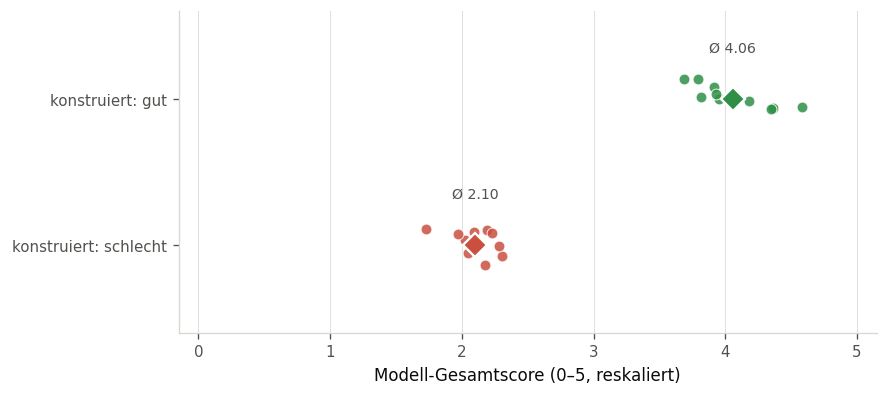

In [8]:
extrem_merged["gruppe"] = np.where(
    extrem_merged["file"].str.startswith("good_"), "konstruiert: gut", "konstruiert: schlecht"
)
gruppen = ["konstruiert: schlecht", "konstruiert: gut"]
farben_gruppe = {"konstruiert: schlecht": VERDICT["schlecht"], "konstruiert: gut": VERDICT["gut"]}

fig, ax = plt.subplots(figsize=(7.5, 3.4))
rng = np.random.default_rng(7)
for i, gname in enumerate(gruppen):
    sub = extrem_merged[extrem_merged["gruppe"] == gname]
    jitter = rng.uniform(-0.14, 0.14, size=len(sub))
    ax.scatter(sub["model_overall_0_5"], np.full(len(sub), i) + jitter, s=42,
               color=farben_gruppe[gname], alpha=0.85, edgecolor="white",
               linewidth=0.6, zorder=3)
    mittel = sub["model_overall_0_5"].mean()
    ax.plot(mittel, i, "D", markersize=10, color=farben_gruppe[gname],
            markeredgecolor="white", markeredgewidth=1.4, zorder=4)
    ax.text(mittel, i + 0.32, f"Ø {mittel:.2f}", ha="center", fontsize=8.5, color=TEXT_SEK)

ax.set_yticks(range(len(gruppen)))
ax.set_yticklabels(gruppen, fontsize=10, color=TEXT)
ax.set_xlabel("Modell-Gesamtscore (0–5, reskaliert)", fontsize=10, color=TEXT)
ax.set_xlim(-0.15, 5.15)
ax.set_ylim(-0.6, len(gruppen) - 0.4)
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
fig.tight_layout()
speichern(fig, "gt_extremfaelle_trennschaerfe")
plt.show()

## Zahlen für Fließtext und Bildunterschriften

In [9]:
print("Kernstichprobe (n=50):")
print(f"  rho gesamt = {kern_result['overall']['spearman_overall']:.3f}")
for d in DIMS:
    c = kern_kennz["ceiling_analyse"][d]
    print(f"  {DIM_DE[d]:<20} rho = {c['spearman_beobachtet']:.3f}  "
          f"Ceiling = {c['spearman_ceiling']:.3f}  Anteil = {c['anteil_vom_ceiling']:.1%}")

print()
print("Extremfälle (n=20):")
print(f"  rho gesamt = {extrem_result['overall']['spearman_overall']:.3f}")
for d in DIMS:
    c = extrem_kennz["ceiling_analyse"][d]
    print(f"  {DIM_DE[d]:<20} rho = {c['spearman_beobachtet']:.3f}  "
          f"Ceiling = {c['spearman_ceiling']:.3f}  Anteil = {c['anteil_vom_ceiling']:.1%}")

print()
print("Trennschärfe Extremfälle:")
for gname in gruppen:
    sub = extrem_merged[extrem_merged["gruppe"] == gname]
    print(f"  {gname:<22} Ø Modell-Gesamtscore (0-5) = {sub['model_overall_0_5'].mean():.2f}  (n={len(sub)})")

Kernstichprobe (n=50):
  rho gesamt = 0.765
  Auffindbarkeit       rho = 0.524  Ceiling = 0.768  Anteil = 68.3%
  Zugänglichkeit       rho = 0.712  Ceiling = 0.952  Anteil = 74.8%
  Wiederverwendbarkeit rho = 0.739  Ceiling = 0.928  Anteil = 79.6%
  Aussagekraft         rho = 0.569  Ceiling = 0.851  Anteil = 66.8%

Extremfälle (n=20):
  rho gesamt = 0.827
  Auffindbarkeit       rho = 0.874  Ceiling = 0.967  Anteil = 90.3%
  Zugänglichkeit       rho = 0.713  Ceiling = 0.978  Anteil = 72.9%
  Wiederverwendbarkeit rho = 0.872  Ceiling = 0.957  Anteil = 91.0%
  Aussagekraft         rho = 0.321  Ceiling = 0.942  Anteil = 34.1%

Trennschärfe Extremfälle:
  konstruiert: schlecht  Ø Modell-Gesamtscore (0-5) = 2.10  (n=10)
  konstruiert: gut       Ø Modell-Gesamtscore (0-5) = 4.06  (n=10)
